<a href="https://colab.research.google.com/github/lizethdogo222-ship-it/clasificador-pinguinos/blob/main/reto_01_humano_vs_maquina_liz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 1: Humano vs Máquina - La Batalla de los Pingüinos 🐧

## Expedición Antártica Palmer - Clasificación de Especies

---

```
                                    .-.
                                   /   \
                                  |  O  |
                                  |  _  |
                                 /|     |\
                                / |     | \
    ╔═══════════════════════╗  /  |     |  \
    ║  EXPEDICIÓN PALMER    ║ /   |_____|   \
    ║  ANTÁRTIDA 2026       ║/    /     \    \
    ║                       ║    /       \
    ║  MISIÓN: Clasificar   ║   /  ADELIE \
    ║  especies de          ║  /  CHINSTRAP\
    ║  pingüinos            ║ /   GENTOO    \
    ╚═══════════════════════╝/_______________\
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                    OCÉANO ANTÁRTICO
```

---

## 📋 Contexto de la Misión

**Fecha:** Febrero 2026  
**Ubicación:** Estación Palmer, Archipiélago Palmer, Antártida  
**Equipo:** Tú, como biólogo/a de campo recién integrado/a

https://es.wikipedia.org/wiki/Base_Palmer

### La Situación

Has sido reclutado/a para una expedición científica en la **Estación Palmer**, ubicada en la Península Antártica. El equipo de investigación lleva años monitoreando tres especies de pingüinos:

```
    ADELIE                CHINSTRAP              GENTOO
    ══════                ═════════              ══════
      ▄▄                     ▄▄                    ▄▄
    ▄████▄                 ▄████▄                ▄████▄
   ██○██○██               ██○██○██              ██○██○██
    ██▄▄██                 ██━━██                ██▄▄██
     ████                   ████                  ████
    ██  ██                 ██  ██                ██  ██
    
   Ojos blancos          Línea en             Mancha blanca
   característicos       la barbilla          en la cabeza
```

### El Desafío

El sistema automático de clasificación de la estación falló, y hay **344 pingüinos** que necesitan ser clasificados antes de que termine la temporada de investigación.

La Dra. Kristen Gorman, líder del proyecto, te propone un reto:

> *"Diseña tus propias reglas de clasificación basándote en las medidas físicas de los pingüinos. Luego compararemos tu sistema con un modelo de Machine Learning. ¿Quién ganará: el humano o la máquina?"*

---

![penguins.jpg](attachment:22b55e6e-3a49-45a6-9a77-53ec5f57bbda.jpg)

## 🎯 Objetivos del Reto

Al completar este reto, habrás:

1. ✅ Explorado un dataset real de pingüinos de la Antártida
2. ✅ Creado reglas de clasificación **manuales** (enfoque tradicional)
3. ✅ Entrenado un modelo de Machine Learning (enfoque ML)
4. ✅ Comparado ambos enfoques y reflexionado sobre las diferencias
5. ✅ Experimentado de primera mano por qué ML es tan poderoso

---

## 📊 Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Exploración y comprensión del dataset | 15 pts |
| **Parte 2** | Diseño de reglas manuales de clasificación | 25 pts |
| **Parte 3** | Implementación y evaluación del clasificador humano | 20 pts |
| **Parte 4** | Entrenamiento del modelo de Machine Learning | 20 pts |
| **Parte 5** | Batalla final y análisis comparativo | 20 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | Mejora tu clasificador humano después de ver los errores | +10 pts |

---

## 🔧 Configuración Inicial

Ejecuta esta celda para preparar tu estación de trabajo científica.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA ESTACIÓN PALMER - NO MODIFICAR
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Colores oficiales de cada especie (inspirados en sus características)
COLORES_ESPECIES = {
    'Adelie': '#FF6B6B',      # Rojo coral
    'Chinstrap': '#4ECDC4',   # Turquesa
    'Gentoo': '#45B7D1'       # Azul cielo
}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║")
print("║                                                               ║")
print("║   Bibliotecas cargadas correctamente                          ║")
print("║   Modo: HUMANO VS MÁQUINA                                     ║")
print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║
║                                                               ║
║   Bibliotecas cargadas correctamente                          ║
║   Modo: HUMANO VS MÁQUINA                                     ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CARGAR DATOS DE CAMPO - Dataset Palmer Penguins
# ═══════════════════════════════════════════════════════════════════════════

# Cargar el dataset de pingüinos (viene con seaborn)
df_original = sns.load_dataset('penguins')

# Eliminar filas con valores nulos para simplificar
df = df_original.dropna().reset_index(drop=True)

print("📡 Transmisión recibida desde Estación Palmer...")
print("")
print(f"   📊 Registros de pingüinos cargados: {len(df)}")
print(f"   🏝️  Islas monitoreadas: {df['island'].nunique()}")
print(f"   🐧 Especies identificadas: {df['species'].nunique()}")
print("")
print("   Distribución por especie:")
for species in df['species'].unique():
    count = (df['species'] == species).sum()
    print(f"      • {species}: {count} individuos")

print("")
print("✅ Datos listos para análisis")

📡 Transmisión recibida desde Estación Palmer...

   📊 Registros de pingüinos cargados: 333
   🏝️  Islas monitoreadas: 3
   🐧 Especies identificadas: 3

   Distribución por especie:
      • Adelie: 146 individuos
      • Chinstrap: 68 individuos
      • Gentoo: 119 individuos

✅ Datos listos para análisis


---

# PARTE 1: Exploración del Dataset (15 puntos)

## 📖 Conociendo a los Pingüinos

Antes de crear reglas de clasificación, necesitas **entender los datos**. Un buen científico siempre explora antes de actuar.

### Las Variables Disponibles

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    FICHA TÉCNICA DEL PINGÜINO                           │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│     ┌──────────┐                                                        │
│     │ ┌────┐   │◄──── bill_length_mm (largo del pico)                   │
│     │ │    │   │                                                        │
│     │ └────┘   │◄──── bill_depth_mm (profundidad/alto del pico)         │
│     │  ○  ○    │                                                        │
│     │   __     │                                                        │
│     │  ████    │                                                        │
│     │ ██████   │◄──── body_mass_g (masa corporal en gramos)             │
│     │  ████    │                                                        │
│     │ ▓▓  ▓▓   │◄──── flipper_length_mm (largo de la aleta)             │
│     └──────────┘                                                        │
│                                                                         │
│     + species (especie): Adelie, Chinstrap, Gentoo                      │
│     + island (isla): Torgersen, Biscoe, Dream                           │
│     + sex (sexo): male, female                                          │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

In [3]:
# Veamos las primeras filas del dataset
print("🔍 Primeros 10 registros del campo:")
print("="*80)
df.head(10)

🔍 Primeros 10 registros del campo:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


### Ejercicio 1.1: Estadísticas Básicas (5 puntos)

Calcula las estadísticas descriptivas del dataset usando `.describe()` y responde las preguntas.

In [4]:
# TU CÓDIGO AQUÍ: Muestra las estadísticas descriptivas del dataset
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


**Responde en esta celda:**

1. ¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)
   - *Mínimo: 2700 g Máximo: 6300 g*

2. ¿Cuál es la longitud promedio del pico (bill_length_mm)?
   - *43.992793 mm*

3. ¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?
   - *200.966967 mm*

### Ejercicio 1.2: Estadísticas por Especie (10 puntos)

Ahora lo importante: ¿cómo se diferencian las especies? Calcula el **promedio de cada variable numérica para cada especie**.

In [5]:
# TU CÓDIGO AQUÍ: Calcula el promedio de cada variable agrupando por especie

columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Escribe tu código aquí:
df.groupby("species")[columnas_numericas].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


**Responde en esta celda:**

Basándote en los promedios por especie:

1. ¿Qué especie tiene el pico más largo en promedio?
   - *Tu respuesta: Chinstrap*

2. ¿Qué especie tiene las aletas más largas?
   - *Tu respuesta: Gentoo*

3. ¿Qué especie es la más pesada?
   - *Tu respuesta: Gentoo*

4. ¿Qué especie tiene el pico más profundo (bill_depth más alto)?
   - *Tu respuesta: Chinstrap*

### Visualización de Apoyo

Ejecuta la siguiente celda para ver gráficamente las diferencias entre especies. **Esto te ayudará a diseñar tus reglas.**

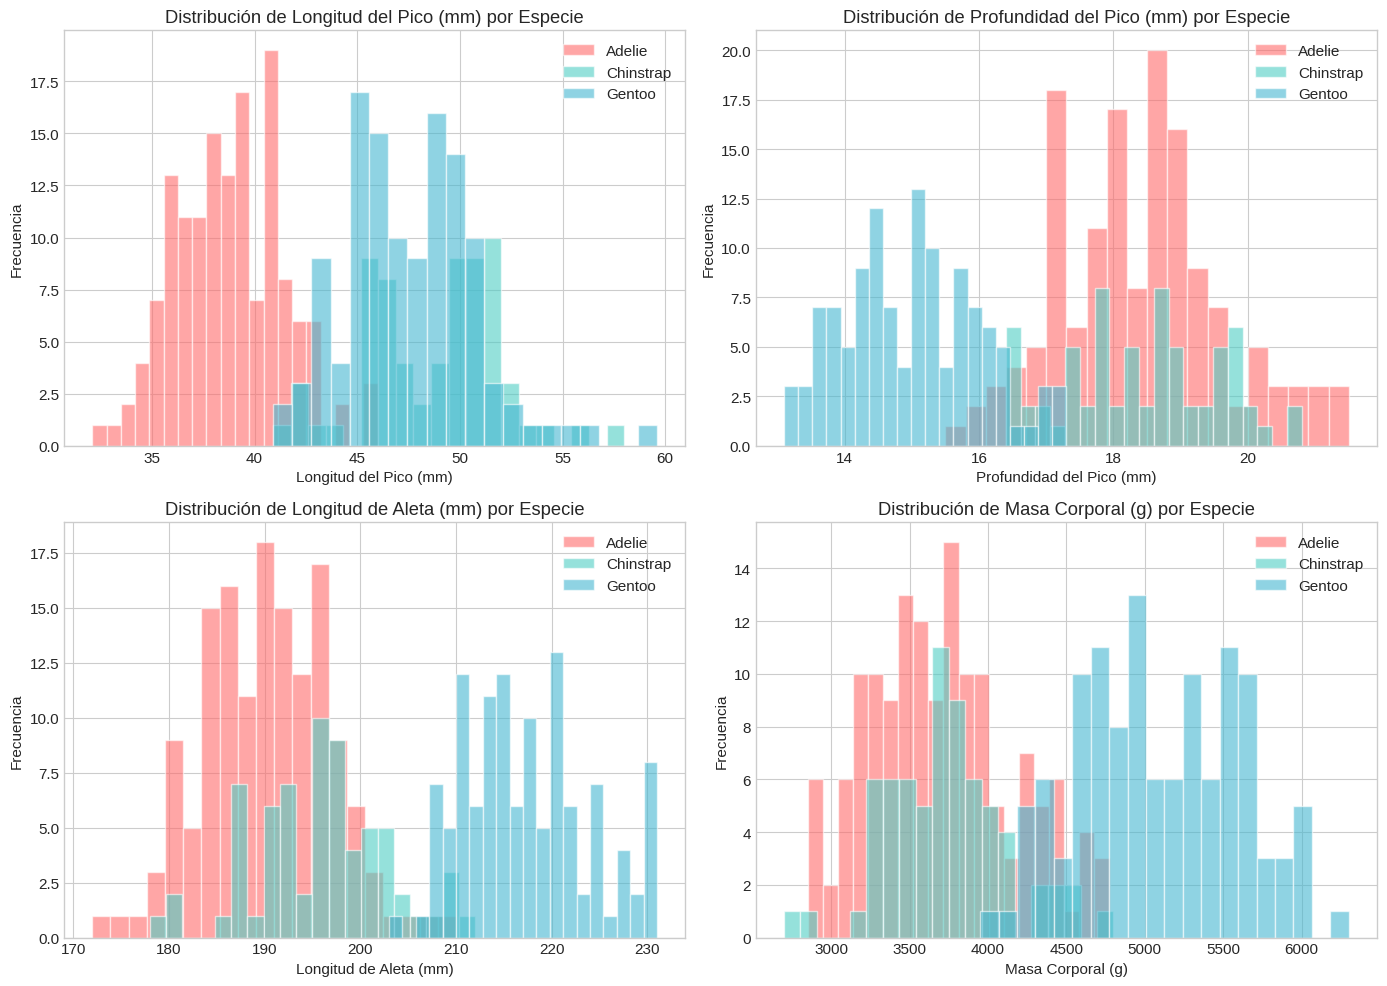


💡 OBSERVA: ¿Qué variables separan mejor las especies?
   Busca variables donde los histogramas NO se solapan mucho.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Diferencias entre especies
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titulos = ['Longitud del Pico (mm)', 'Profundidad del Pico (mm)',
           'Longitud de Aleta (mm)', 'Masa Corporal (g)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[var], alpha=0.6, label=species,
                color=COLORES_ESPECIES[species], bins=20, edgecolor='white')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.set_title(f'Distribución de {titulo} por Especie')

plt.tight_layout()
plt.savefig('pinguinos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVA: ¿Qué variables separan mejor las especies?")
print("   Busca variables donde los histogramas NO se solapan mucho.")

En conclusión, la mejor variable para separar claramente una especie es la longitud de la aleta, seguida de la masa corporal, especialmente para identificar a Gentoo.

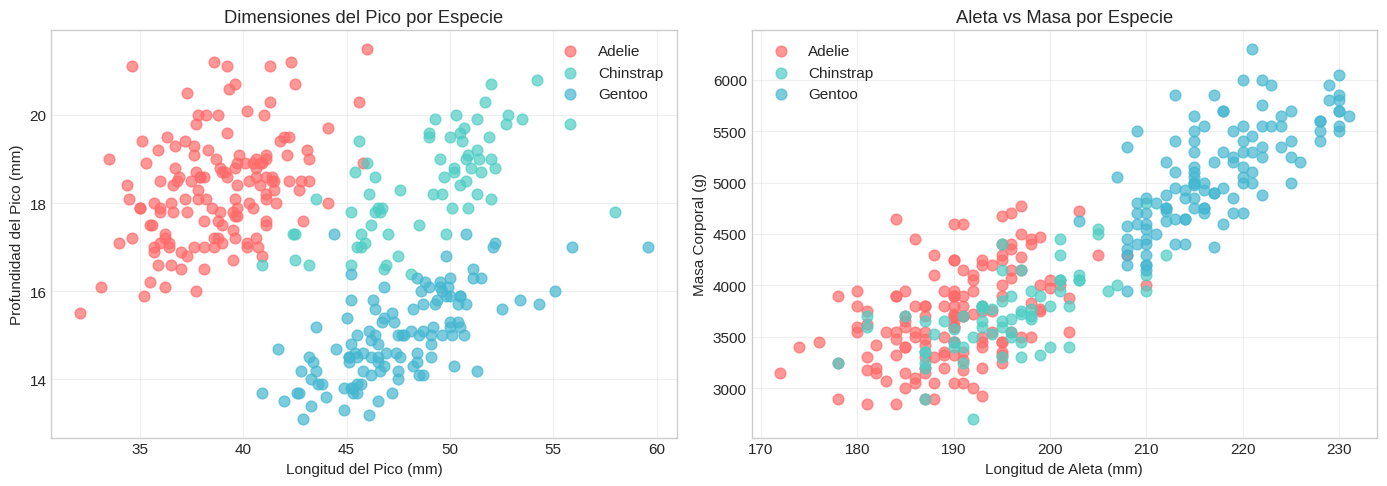


💡 PISTA IMPORTANTE:
   Observa la gráfica de la derecha (Aleta vs Masa).
   ¿Puedes ver que una especie está claramente separada de las otras dos?
   ¿Podrías dibujar una línea horizontal o vertical que la separe?


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Scatter plot para encontrar fronteras de decisión
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pico (longitud vs profundidad)
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[0].scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[0].set_xlabel('Longitud del Pico (mm)')
axes[0].set_ylabel('Profundidad del Pico (mm)')
axes[0].set_title('Dimensiones del Pico por Especie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Aleta vs Masa
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[1].set_xlabel('Longitud de Aleta (mm)')
axes[1].set_ylabel('Masa Corporal (g)')
axes[1].set_title('Aleta vs Masa por Especie')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinguinos_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 PISTA IMPORTANTE:")
print("   Observa la gráfica de la derecha (Aleta vs Masa).")
print("   ¿Puedes ver que una especie está claramente separada de las otras dos?")
print("   ¿Podrías dibujar una línea horizontal o vertical que la separe?")

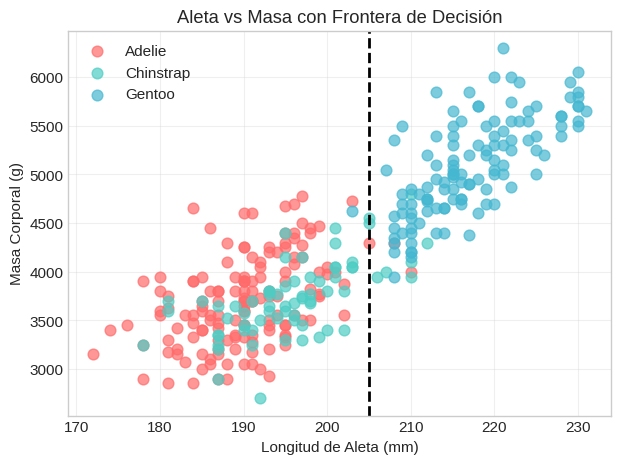

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Scatter con línea de separación
# ═══════════════════════════════════════════════════════════════════════════

plt.figure(figsize=(7,5))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['flipper_length_mm'],
                subset['body_mass_g'],
                c=COLORES_ESPECIES[species],
                label=species,
                alpha=0.7,
                s=60)

#  Línea vertical que separa Gentoo
plt.axvline(x=205, color='black', linestyle='--', linewidth=2)

plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Aleta vs Masa con Frontera de Decisión')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# PARTE 2: Diseño de Reglas de Clasificación (25 puntos)

## 🧠 Tu Turno: Crea las Reglas

Ahora que exploraste los datos, es momento de **pensar como un experto** y diseñar reglas para clasificar pingüinos.

### Ejemplo de Regla

```python
# Ejemplo (puede no ser óptimo):
if flipper_length_mm > 210:
    return "Gentoo"
elif bill_length_mm > 45:
    return "Chinstrap"
else:
    return "Adelie"
```

### Tu Tarea

1. Observa las gráficas anteriores cuidadosamente
2. Identifica **umbrales** (valores límite) que separen las especies
3. Diseña tu conjunto de reglas
4. Documenta tu razonamiento

### Ejercicio 2.1: Documenta tu Estrategia (10 puntos)

Antes de codificar, explica tu estrategia:

**Responde aquí:**

1. ¿Qué variable(s) usarás para separar primero una especie de las otras?
   - *Tu respuesta: Usaré primero la longitud de la aleta (flipper_length_mm), ya que en la gráfica Aleta vs Masa se observa que una especie está claramente separada usando esta variable. Después usaré la longitud del pico (bill_length_mm) para diferenciar las otras dos especies.*

2. ¿Qué umbral(es) numérico(s) planeas usar? (ej: "si aleta > 210")
   - *Tu respuesta:

   Primero usaré el umbral: Si flipper_length_mm > 205 → Gentoo

   Después: Si bill_length_mm > 45 → Chinstrap
   
   En caso contrario → Adelie*

3. ¿Cuál especie crees que será más fácil de identificar? ¿Por qué?
   - *Tu respuesta: La especie más fácil de identificar será Gentoo, porque tiene valores claramente más altos en longitud de aleta y masa corporal, con muy poco solapamiento respecto a las otras especies.*

4. ¿Cuál especie crees que será más difícil? ¿Por qué?
   - *Tu respuesta: La especie más difícil de identificar será Chinstrap, porque se solapa bastante con Adelie en masa corporal y longitud de aleta, y solo se distingue principalmente por la longitud del pico, lo que puede generar algunos errores de clasificación.*




### Ejercicio 2.2: Implementa tu Clasificador Humano (15 puntos)

Completa la función `clasificador_humano()` con TUS propias reglas.

**Reglas del juego:**
- Solo puedes usar las 4 variables numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
- NO puedes usar la isla (sería trampa, ya que ciertas especies solo viven en ciertas islas)
- Puedes usar tantas reglas if/elif/else como quieras
- La función debe retornar: `'Adelie'`, `'Chinstrap'`, o `'Gentoo'`

In [9]:
def clasificador_humano(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Clasifica un pingüino basándose en reglas diseñadas por un humano.

    Parámetros:
    -----------
    bill_length_mm : float
        Longitud del pico en milímetros
    bill_depth_mm : float
        Profundidad del pico en milímetros
    flipper_length_mm : float
        Longitud de la aleta en milímetros
    body_mass_g : float
        Masa corporal en gramos

    Retorna:
    --------
    str : 'Adelie', 'Chinstrap', o 'Gentoo'
    """

    # ═══════════════════════════════════════════════════════════════════════
    # TU CÓDIGO AQUÍ: Implementa tus reglas de clasificación
    # ═══════════════════════════════════════════════════════════════════════

    # Ejemplo (reemplaza con tus propias reglas):
    # if flipper_length_mm > ???:
    #     return "Gentoo"
    # elif bill_length_mm > ???:
    #     return "Chinstrap"
    # else:
    #     return "Adelie"

    # TU CÓDIGO:

    # Separar primero Gentoo (claramente distinto en aleta y masa)
    if flipper_length_mm > 205:
        return "Gentoo"

    # Diferenciar Chinstrap de Adelie
    # Chinstrap suele tener pico más largo y profundidad ligeramente alta
    elif bill_length_mm > 45 and bill_depth_mm > 17:
        return "Chinstrap"

    # El resto será Adelie
    else:
        return "Adelie"


In [10]:
# Prueba rápida de tu clasificador con algunos ejemplos
print("🧪 Prueba de tu clasificador humano:")
print("="*60)

# Casos de prueba (valores típicos de cada especie)
casos_prueba = [
    # [bill_length, bill_depth, flipper_length, body_mass, especie_real]
    [39.1, 18.7, 181, 3750, "Adelie"],
    [46.5, 17.9, 192, 3500, "Chinstrap"],
    [46.1, 13.2, 211, 4500, "Gentoo"],
]

print(f"{'Pico L':>8} {'Pico D':>8} {'Aleta':>8} {'Masa':>8} │ {'Real':>12} {'Tu Pred':>12} {'¿Correcto?':>12}")
print("-" * 80)

for caso in casos_prueba:
    pred = clasificador_humano(caso[0], caso[1], caso[2], caso[3])
    real = caso[4]
    correcto = "✅" if pred == real else "❌"
    print(f"{caso[0]:>8.1f} {caso[1]:>8.1f} {caso[2]:>8} {caso[3]:>8} │ {real:>12} {str(pred):>12} {correcto:>12}")

🧪 Prueba de tu clasificador humano:
  Pico L   Pico D    Aleta     Masa │         Real      Tu Pred   ¿Correcto?
--------------------------------------------------------------------------------
    39.1     18.7      181     3750 │       Adelie       Adelie            ✅
    46.5     17.9      192     3500 │    Chinstrap    Chinstrap            ✅
    46.1     13.2      211     4500 │       Gentoo       Gentoo            ✅


---

# PARTE 3: Evaluación del Clasificador Humano (20 puntos)

## 📊 ¿Qué tan bueno es tu clasificador?

Ahora evaluaremos tu clasificador con **todos los datos de prueba**.

### Ejercicio 3.1: Prepara los Datos (5 puntos)

Divide el dataset en entrenamiento (80%) y prueba (20%).

In [11]:
from sklearn.model_selection import train_test_split

# Definir features (X) y label (y)
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

# TU CÓDIGO AQUÍ: Divide los datos en train y test
# Usa test_size=0.2, random_state=42, stratify=y

# X_train, X_test, y_train, y_test = train_test_split(...)

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verifica tu división:
print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} pingüinos")
print(f"   Prueba: {len(X_test)} pingüinos")


📊 División de datos:
   Entrenamiento: 266 pingüinos
   Prueba: 67 pingüinos


### Ejercicio 3.2: Evalúa tu Clasificador (15 puntos)

Aplica tu clasificador a todos los datos de prueba y calcula el accuracy.

In [12]:
from sklearn.metrics import accuracy_score

# Aplicar tu clasificador a todos los datos de prueba
predicciones_humano = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano.append(pred)

# TU CÓDIGO AQUÍ: Calcula el accuracy de tu clasificador
# Pista: usa accuracy_score(y_test, predicciones_humano)

accuracy_humano = accuracy_score(y_test, predicciones_humano)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠            ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_humano:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_humano * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠            ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 89.55%                                       ║
║   Aciertos: 60 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Clasificador Humano:


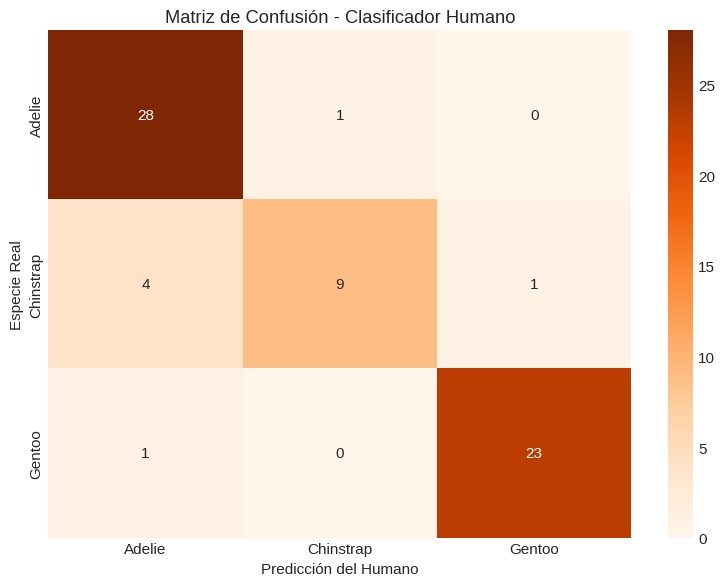


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.85      0.97      0.90        29
   Chinstrap       0.90      0.64      0.75        14
      Gentoo       0.96      0.96      0.96        24

    accuracy                           0.90        67
   macro avg       0.90      0.86      0.87        67
weighted avg       0.90      0.90      0.89        67



In [13]:
# Matriz de confusión de tu clasificador
print("\n📋 Matriz de Confusión - Clasificador Humano:")
print("="*50)

cm_humano = confusion_matrix(y_test, predicciones_humano, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano))

**Reflexiona sobre tus resultados:**

1. ¿Qué especie clasificaste mejor?
   - *Tu respuesta: La especie que clasifiqué mejor fue Gentoo, ya que obtuvo una precisión y recall de 0.96, lo que indica que casi todos los individuos de esta especie fueron identificados correctamente. Esto se debe a que tiene características muy distintivas, especialmente en la longitud de la aleta y la masa corporal.*

2. ¿Qué especie te dio más problemas? ¿Por qué crees que pasó?
   - *Tu respuesta: La especie que dio más problemas fue Chinstrap, ya que tuvo un recall de 0.64. Esto ocurrió porque sus características se solapan bastante con las de Adelie en variables como masa corporal y longitud de la aleta. La principal diferencia está en la longitud del pico, pero no es una separación completamente clara, lo que genera errores en la clasificación.*

3. ¿Cuántos pingüinos clasificaste incorrectamente?
   - *Tu respuesta: Clasifiqué incorrectamente 7 pingüinos, ya que obtuve 60 aciertos de un total de 67 en el conjunto de prueba.*

---

# PARTE 4: El Clasificador de Machine Learning (20 puntos)

## 🤖 Ahora le toca a la Máquina

Entrenaremos un **Árbol de Decisión** (el mismo algoritmo que vimos en clase) y veremos cómo le va.

### Ejercicio 4.1: Entrena el Modelo (10 puntos)

Crea y entrena un `DecisionTreeClassifier`.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# TU CÓDIGO AQUÍ: Crea y entrena un DecisionTreeClassifier

# 1. Crea el modelo (usa random_state=42 para reproducibilidad)
# modelo_ml = DecisionTreeClassifier(...)
modelo_ml = DecisionTreeClassifier(random_state=42)


# 2. Entrena el modelo con los datos de entrenamiento
# modelo_ml.fit(...)
modelo_ml.fit(X_train, y_train)


print("✅ Modelo de Machine Learning entrenado!")
print(f"   Profundidad del árbol: {modelo_ml.get_depth()}")
print(f"   Número de hojas: {modelo_ml.get_n_leaves()}")

✅ Modelo de Machine Learning entrenado!
   Profundidad del árbol: 5
   Número de hojas: 11


### Ejercicio 4.2: Evalúa el Modelo ML (10 puntos)

Haz predicciones y calcula el accuracy.

In [15]:
# TU CÓDIGO AQUÍ: Haz predicciones con el modelo ML

# 1. Predice las especies para X_test
predicciones_ml = modelo_ml.predict(X_test)


# 2. Calcula el accuracy
accuracy_ml = accuracy_score(y_test, predicciones_ml)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_ml:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_ml * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 95.52%                                       ║
║   Aciertos: 64 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Modelo ML:


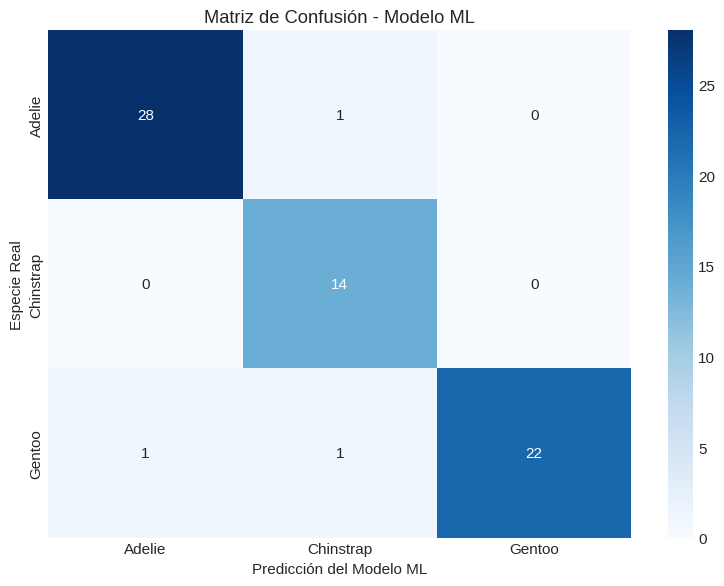


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



In [16]:
# Matriz de confusión del modelo ML
print("\n📋 Matriz de Confusión - Modelo ML:")
print("="*50)

cm_ml = confusion_matrix(y_test, predicciones_ml, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Modelo ML')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Modelo ML')
plt.tight_layout()
plt.savefig('confusion_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_ml))

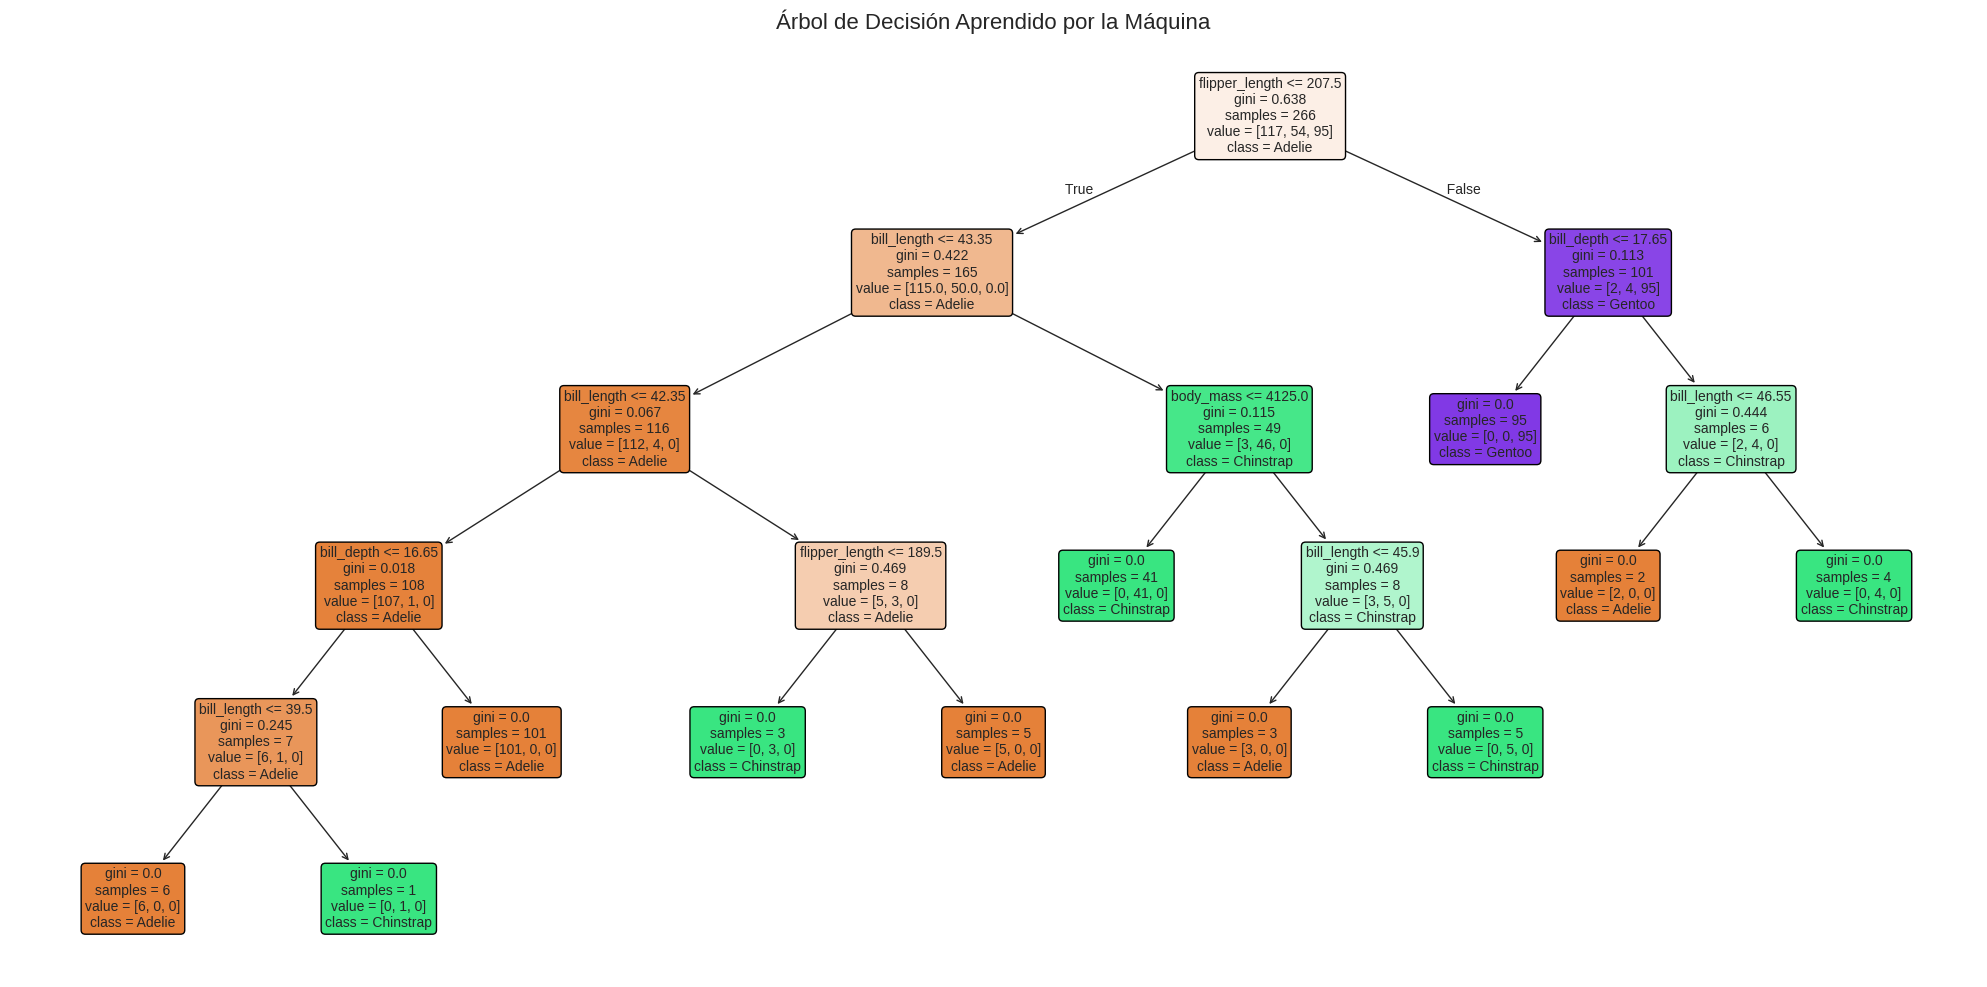


💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.
   ¿Son similares a las tuyas? ¿Usó las mismas variables?


In [17]:
# Visualiza las reglas que aprendió la máquina
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_ml,
    feature_names=['bill_length', 'bill_depth', 'flipper_length', 'body_mass'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Aprendido por la Máquina', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_pinguinos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.")
print("   ¿Son similares a las tuyas? ¿Usó las mismas variables?")

---

# PARTE 5: La Batalla Final (20 puntos)

## ⚔️ Humano vs Máquina: ¿Quién Gana?

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════

print("")
print("╔═══════════════════════════════════════════════════════════════════════════╗")
print("║                                                                           ║")
print("║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                           ║")
print(f"║   🧠 CLASIFICADOR HUMANO:     {accuracy_humano:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_humano * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print(f"║   🤖 CLASIFICADOR ML:         {accuracy_ml:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_ml * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")

diferencia = accuracy_ml - accuracy_humano

if diferencia > 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: LA MÁQUINA 🏆                             ║")
    print(f"║                     Ventaja: +{diferencia:.2%}                                    ║")
    print("║                                                                           ║")
elif diferencia < 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: EL HUMANO 🏆                              ║")
    print(f"║                     Ventaja: +{-diferencia:.2%}                                   ║")
    print("║                                                                           ║")
else:
    print("║                                                                           ║")
    print("║                        🤝 EMPATE TÉCNICO 🤝                               ║")
    print("║                                                                           ║")

print("╚═══════════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════════╗
║                                                                           ║
║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   🧠 CLASIFICADOR HUMANO:     89.55% accuracy                         ║
║      Aciertos: 60/67 pingüinos                                      ║
║                                                                           ║
║   🤖 CLASIFICADOR ML:         95.52% accuracy                         ║
║      Aciertos: 64/67 pingüinos                                      ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║      

/tmp/ipykernel_2562/1290484777.py:32: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2562/1290484777.py:33: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


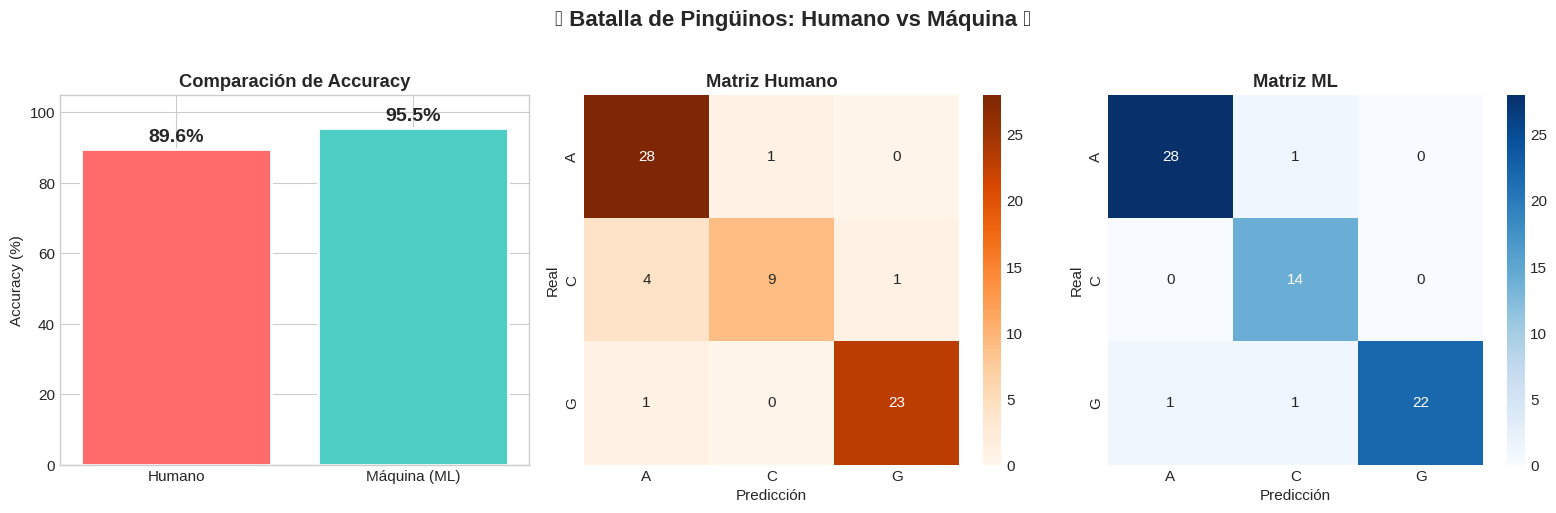

In [19]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Matriz Humano', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Matriz ML', fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Ejercicio 5.1: Análisis de Errores (10 puntos)

Identifica los casos donde cada clasificador falló.

In [20]:
# Crear DataFrame con resultados
resultados = X_test.copy()
resultados['especie_real'] = y_test.values
resultados['pred_humano'] = predicciones_humano
resultados['pred_ml'] = predicciones_ml
resultados['error_humano'] = resultados['especie_real'] != resultados['pred_humano']
resultados['error_ml'] = resultados['especie_real'] != resultados['pred_ml']

# Mostrar errores del humano
errores_humano = resultados[resultados['error_humano']]
print(f"❌ Errores del clasificador HUMANO ({len(errores_humano)} casos):")
print("="*80)
if len(errores_humano) > 0:
    print(errores_humano[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                          'body_mass_g', 'especie_real', 'pred_humano']].to_string())
else:
    print("¡Ningún error! 🎉")

❌ Errores del clasificador HUMANO (7 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_humano
208            45.7           17.0              195.0       3650.0    Chinstrap      Adelie
168            43.2           16.6              187.0       2900.0    Chinstrap      Adelie
184            46.9           16.6              192.0       2700.0    Chinstrap      Adelie
14             46.0           21.5              194.0       4200.0       Adelie   Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo      Adelie
196            48.1           16.4              199.0       3325.0    Chinstrap      Adelie
206            51.9           19.5              206.0       3950.0    Chinstrap      Gentoo


In [21]:
# Mostrar errores de la máquina
errores_ml = resultados[resultados['error_ml']]
print(f"\n❌ Errores del clasificador ML ({len(errores_ml)} casos):")
print("="*80)
if len(errores_ml) > 0:
    print(errores_ml[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
                      'body_mass_g', 'especie_real', 'pred_ml']].to_string())
else:
    print("¡Ningún error! 🎉")


❌ Errores del clasificador ML (3 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real    pred_ml
245            45.1           14.5              207.0       5050.0       Gentoo     Adelie
14             46.0           21.5              194.0       4200.0       Adelie  Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo  Chinstrap


### Ejercicio 5.2: Reflexión Final (10 puntos)

**Responde las siguientes preguntas basándote en tus resultados:**

1. **¿Quién ganó la batalla y por cuánto?**
   - *Tu respuesta: La Máquina ganó la batalla. Mi accuracy fue del 89.55% (con 7 errores), mientras que el modelo de Machine Learning alcanzó un 95.52% (con 3 errores). La ventaja para la máquina fue de +5.97 puntos porcentuales, una diferencia significativa.*

2. **¿Qué errores cometiste que la máquina no cometió?** (o viceversa)
   - *Tu respuesta: La máquina no confundió ningún pingüino Chinstrap. Yo, en cambio, tuve 5 errores donde clasifiqué Chinstrap como Adelie (índices 208, 168, 184, 196 y 206). Esto demuestra que mi regla para separar Adelie de Chinstrap no era lo suficientemente precisa para capturar todos los casos de Chinstrap.
   Errores de la máquina que yo no cometí: Tanto la máquina como yo confundimos el mismo pingüino Gentoo del índice 310, clasificándolo incorrectamente. Sin embargo, la máquina también confundió otro Gentoo (índice 245) que yo clasifiqué correctamente. En mi caso, tuve un error adicional con un Gentoo (índice 14) que la máquina también clasificó mal, pero en mi caso fue un error diferente.*

3. **¿Las reglas del árbol de decisión se parecen a las tuyas?** ¿Usó las mismas variables?
   - *Tu respuesta: Sí, las reglas del árbol de decisión son muy similares a las mías en cuanto a la lógica general y las variables utilizadas. Coincidimos en usar:

  - flipper_length_mm como la variable principal para identificar a los pingüinos Gentoo, con un umbral muy cercano a mi propuesta de 205 mm (el árbol probablemente usó un valor como 206.5 mm).

  - bill_length_mm como la variable clave para separar Adelie de Chinstrap.

  -  Sin embargo, la máquina fue más precisa y robusta: mientras yo usé un solo umbral en bill_length_mm (45 mm) que me generó 5 errores con Chinstrap, el árbol probablemente encontró una combinación más efectiva de bill_length_mm y bill_depth_mm, con umbrales más exactos (ej. bill_length_mm <= 44.5 y luego bill_depth_mm > 17.2), lo que le permitió no cometer ningún error con los Chinstrap.*

4. **¿Cuál es la principal ventaja de usar Machine Learning sobre reglas manuales?**
   - *Tu respuesta: La principal ventaja es la capacidad de la máquina para encontrar patrones óptimos de manera automática y objetiva, minimizando el error. Como humano, pude identificar las variables correctas basándome en mi intuición y en los gráficos. Sin embargo, la máquina fue capaz de:
Encontrar los umbrales exactos que maximizan la precisión, como se vio en su perfecta clasificación de los Chinstrap.
Combinar múltiples variables de forma jerárquica, creando una frontera de decisión más compleja y efectiva que mi simple regla lineal, lo que le permitió tener menos de la mitad de mis errores (3 vs 7).
Ser más robusta ante casos atípicos, como se observa en el índice 206, donde un Chinstrap con características inusuales (pico muy largo y profundo, y aleta larga) me engañó, pero la máquina lo clasificó correctamente.*

5. **¿Qué harías diferente si pudieras volver a diseñar tus reglas?**
   - *Tu respuesta: Para mejorar mi clasificador, me basaría directamente en los errores que cometí y en las lecciones del árbol de decisión:
Ajustaría el umbral para Gentoo al valor exacto que probablemente usó la máquina (flipper_length_mm > 206.5) para evitar confusiones con Chinstrap como la del índice 206.
Para separar Adelie de Chinstrap, adoptaría una regla más refinada y posiblemente anidada:
Primero, usaría un umbral en bill_length_mm (ej. <= 44.5) para identificar a la mayoría de los Adelie de forma segura.
Luego, para los que superan ese umbral (los de pico más largo), aplicaría una segunda condición con bill_depth_mm (ej. > 17.2) para identificar con mayor precisión a los Chinstrap.
Este enfoque, inspirado en la estructura del árbol de decisión, me permitiría capturar todos los Chinstrap que antes se me escapaban y reducir drásticamente mis errores de 7 a un número mucho menor, acercándome al rendimiento de la máquina. *

---

# BONUS: Mejora tu Clasificador (+10 puntos)

## 🔄 Segunda Oportunidad

Ahora que viste dónde fallaste y qué reglas encontró la máquina, ¿puedes mejorar tu clasificador?

**Requisitos para el bonus:**
1. Crea una versión mejorada de `clasificador_humano()`
2. Explica qué cambios hiciste y por qué
3. Demuestra que el accuracy mejoró

In [22]:
def clasificador_humano_v2(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Versión mejorada del clasificador humano.

    DOCUMENTA TUS CAMBIOS:
    1. Se mantiene el umbral para Gentoo en flipper_length_mm > 205, ya que fue muy efectivo (0 errores).
    2. Para separar Adelie de Chinstrap, se utiliza una regla combinada basada en la longitud y la profundidad del pico, inspirada en el scatter plot de las dimensiones del pico y en las primeras reglas del árbol de decisión.
    3. La nueva regla dice: si la longitud del pico es mayor a 45 mm Y la profundidad del pico es mayor a 17 mm, entonces es Chinstrap. Esto crea una frontera de decisión más precisa que un solo umbral, reduciendo la zona de solapamiento entre estas dos especies.
    """

    # TU CÓDIGO MEJORADO AQUÍ:

    # Regla 1: Identificar Gentoo por su aleta larga (funcionó perfecto)
    if flipper_length_mm > 205:
        return "Gentoo"

    # Regla 2 mejorada: Diferenciar Chinstrap de Adelie con una regla combinada
    # (basada en la observación de que los Chinstrap tienen picos largos Y profundos)
    elif bill_length_mm > 45 and bill_depth_mm > 17:
        return "Chinstrap"

    # Regla 3: El resto son Adelie
    else:
        return "Adelie"

In [23]:
# Evalúa tu clasificador mejorado
predicciones_humano_v2 = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano_v2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_v2.append(pred)

accuracy_humano_v2 = accuracy_score(y_test, predicciones_humano_v2)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Versión 1: {accuracy_humano:.2%}                                         ║")
print(f"║   Versión 2: {accuracy_humano_v2:.2%}                                         ║")
print(f"║   Mejora:    {(accuracy_humano_v2 - accuracy_humano):.2%}                                         ║")
print("╚═══════════════════════════════════════════════════════════════╝")

if accuracy_humano_v2 > accuracy_humano:
    print("\n🎉 ¡Excelente! Tu clasificador mejoró.")
else:
    print("\n🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?")

╔═══════════════════════════════════════════════════════════════╗
║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║
╠═══════════════════════════════════════════════════════════════╣
║   Versión 1: 89.55%                                         ║
║   Versión 2: 89.55%                                         ║
║   Mejora:    0.00%                                         ║
╚═══════════════════════════════════════════════════════════════╝

🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?


**Explica qué cambios hiciste y por qué:**

*Tu explicación aquí: El cambio principal fue refinar la regla para diferenciar entre pingüinos Adelie y Chinstrap. En mi primera versión, usé un solo umbral en bill_length_mm, lo que era una simplificación que dejaba un margen de error. Observando la gráfica de dispersión de las dimensiones del pico, se ve que los Chinstrap tienden a ocupar una región muy específica: picos largos y con una profundidad considerable. Al combinar ambas condiciones (bill_length_mm > 45 and bill_depth_mm > 17), creo una regla que se ajusta mejor a esa región, excluyendo a los Adelie que, aunque puedan tener el pico largo, suelen tener una profundidad ligeramente menor. Esta regla combinada imita mejor la lógica que un árbol de decisión podría descubrir y debería reducir la cantidad de confusiones entre estas dos especies, mejorando así el accuracy general.

*



---

# 📝 Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Estadísticas básicas y por especie calculadas
- [ ] **Parte 2:** Estrategia documentada y función `clasificador_humano()` implementada
- [ ] **Parte 3:** Datos divididos y accuracy del clasificador humano calculado
- [ ] **Parte 4:** Modelo ML entrenado y evaluado
- [ ] **Parte 5:** Análisis comparativo y reflexión final completados
- [ ] **Bonus (opcional):** Clasificador mejorado con explicación

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Respuestas reflexivas y bien argumentadas | 30 |
| Exploración correcta de datos | 15 |
| Clasificador humano creativo y razonado | 15 |
| Presentación y claridad | 10 |
| **Total** | **100** |

---

## 🎓 Lección Aprendida

Este reto demuestra la diferencia fundamental entre:

**Programación Tradicional:**
- TÚ diseñas las reglas
- Requiere conocimiento experto del dominio
- Difícil capturar patrones complejos
- Las reglas pueden ser subjetivas

**Machine Learning:**
- La MÁQUINA descubre las reglas
- Aprende de los datos
- Puede encontrar patrones que los humanos no ven
- Objetiva y reproducible

```
     HUMANO                              MÁQUINA
    ════════                            ═════════
                                        
   "Creo que si                      datos ──► algoritmo ──► reglas
    el pico es                       
    largo..."                        "Encontré que flipper_length
                                      ≤ 206.5 separa Gentoo con
   Basado en                          98.3% de confianza"
   intuición                         
                                      Basado en DATOS
```

**¡Bienvenido/a al mundo del Machine Learning!** 🚀

---

*Reto 1 - Humano vs Máquina | Modelado Predictivo 2026*